### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
df

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9
...,...,...,...,...,...
188,Venezuela,333,100,3,7.7
189,Vietnam,111,2,1,2.0
190,Yemen,6,0,0,0.1
191,Zambia,32,19,4,2.5


medie: 
 beer_servings      106.160622
wine_servings       49.450777
spirit_servings     80.994819
dtype: float64
paese con alcohol index più alto: 
 country                            Andorra
beer_servings                          245
spirit_servings                        138
wine_servings                          312
total_litres_of_pure_alcohol          12.4
alcohol_index                   231.666667
Name: 3, dtype: object
paesi con più di 100 birre anno:                 country  beer_servings  spirit_servings  wine_servings  \
3              Andorra            245              138            312   
4               Angola            217               57             45   
5    Antigua & Barbuda            102              128             45   
6            Argentina            193               25            221   
8            Australia            261               72            212   
..                 ...            ...              ...            ...   
182     United Kingdom  

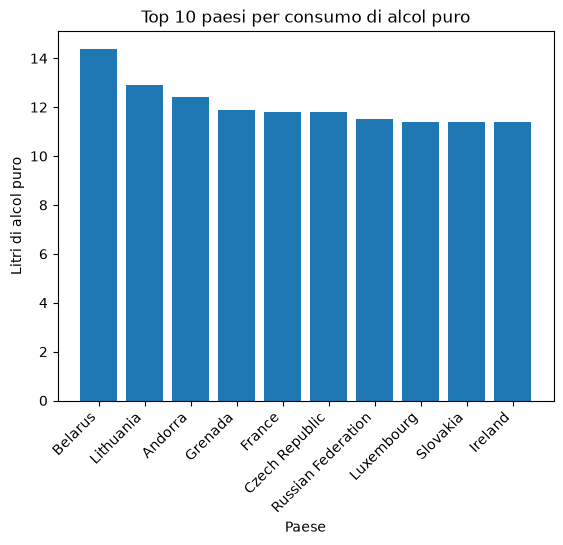

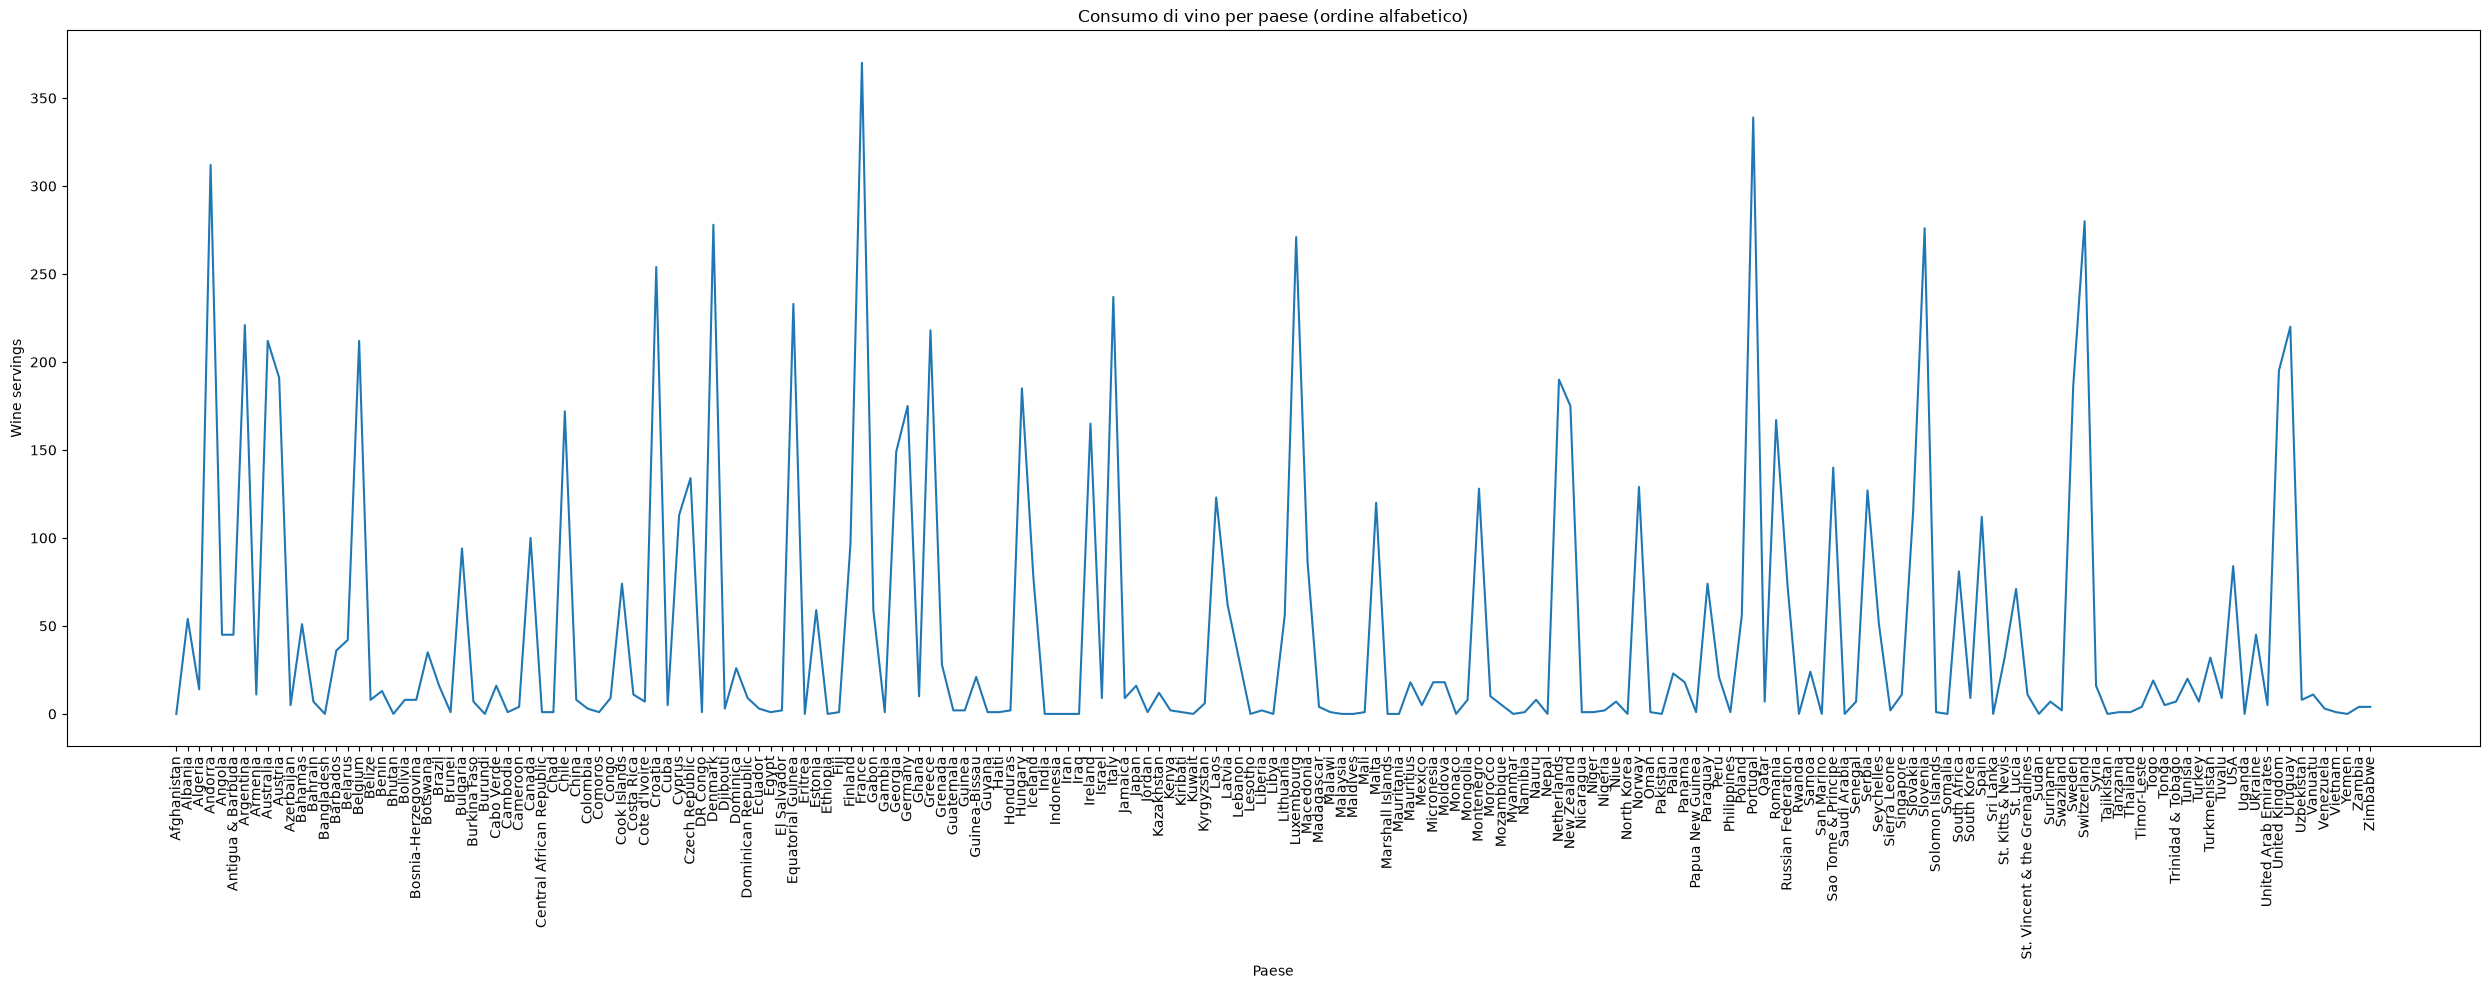

In [32]:
#primi 10 paesi per total_litres_of_pure_alcohol
top10 = df.sort_values(by = 'total_litres_of_pure_alcohol', ascending= False).head(10)
top10

#medie dei consumi
birra = df['beer_servings'].mean()
birra

vino = df['wine_servings'].mean()
vino

distillati = df['spirit_servings'].mean()
distillati

#potevo fare anche tutto assieme
medie = df[['beer_servings', 'wine_servings', 'spirit_servings']].mean()
print('medie: \n', medie)


#colonna alcohol_index
df['alcohol_index'] = (df['beer_servings'] + df['wine_servings'] + df['spirit_servings']) / 3

#paese con alcohol_index piu alto
paese = df.loc[df['alcohol_index'].idxmax()]
print('paese con alcohol index più alto: \n', paese)

#paesi con più di 100 birre anno
birre = df[df['beer_servings'] > 100]
print('paesi con più di 100 birre anno: ', birre)

#bar chart
plt.bar(top10['country'], top10['total_litres_of_pure_alcohol'])
plt.title('Top 10 paesi per consumo di alcol puro')
plt.xlabel('Paese')
plt.ylabel('Litri di alcol puro')
plt.xticks(rotation=45, ha='right')
plt.show()

# line plot wine_servings
df_ordinato = df.sort_values(by='country')
df_ordinato

plt.figure(figsize=(25, 10))#aumentata grandezza del grafico affinche siano leggibili i nomi
plt.plot(df_ordinato['country'], df_ordinato['wine_servings'])
plt.title('Consumo di vino per paese (ordine alfabetico)')
plt.xlabel('Paese')
plt.ylabel('Wine servings')
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

In [33]:
import pandas as pd
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,NaN,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"['bash', 'python', 'perl', 'linux', 'unix', 'k...","{'os': ['linux', 'unix'], 'other': ['kubernete..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,"['sas', 'sas', 'sql', 'excel']","{'analyst_tools': ['sas', 'excel'], 'programmi..."
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,NaN,NaN,NaN,Lendlease Corporation,"['powerpoint', 'excel']","{'analyst_tools': ['powerpoint', 'excel']}"
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,"['python', 'go', 'nosql', 'sql', 'mongo', 'she...","{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."


analisi sul salario: 
                       mean      min       max
job_country                                  
Afghanistan            NaN      NaN       NaN
Albania       79472.500000  43200.0  157500.0
Algeria       44550.000000  44100.0   45000.0
Angola                 NaN      NaN       NaN
Argentina    105212.343750  45000.0  222000.0
...                    ...      ...       ...
Venezuela              NaN      NaN       NaN
Vietnam       90927.236364  28000.0  200000.0
Yemen                  NaN      NaN       NaN
Zambia        90670.000000  90670.0   90670.0
Zimbabwe      67056.666667  47500.0   90670.0

[160 rows x 3 columns]
offerte di lavoro totale: 
 job_country
Afghanistan      16
Albania         119
Algeria         111
Angola           11
Argentina      8736
               ... 
Venezuela        69
Vietnam        2414
Yemen            10
Zambia          104
Zimbabwe         81
Length: 160, dtype: int64


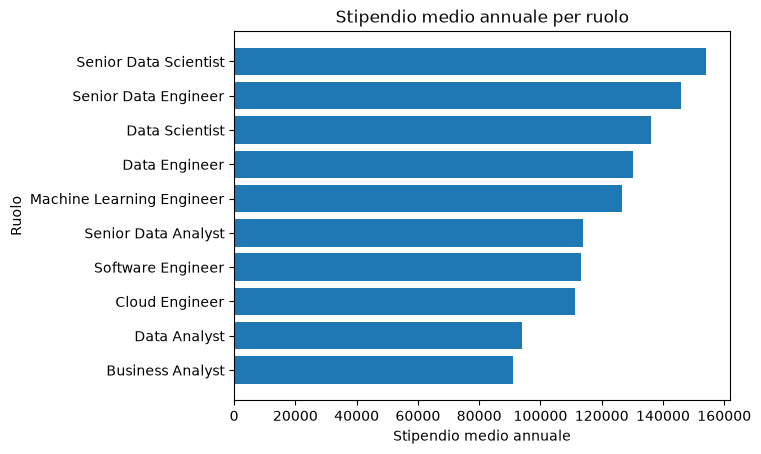

In [34]:
#analisi esplorativa
stats_salario = df.groupby('job_country')['salary_year_avg'].agg(['mean', 'min', 'max'])
offerte_totali = df.groupby('job_country').size()

print('analisi sul salario: \n', stats_salario)
print('offerte di lavoro totale: \n', offerte_totali)

#grafico a barre orizzontali
salari = df.groupby('job_title_short')['salary_year_avg'].mean().sort_values(ascending=True) #stipendio medio per ruolo

#grafico dello stipendio medio per anno
plt.barh(salari.index, salari)
plt.title('Stipendio medio annuale per ruolo')
plt.xlabel('Stipendio medio annuale')
plt.ylabel('Ruolo')
plt.show()

### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

In [35]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


statistiche total_bill per day: 
            mean  count   min    max
day                                
Fri   17.151579     19  5.75  40.17
Sat   20.441379     87  3.07  50.81
Sun   21.410000     76  7.25  48.17
Thur  17.682742     62  7.51  43.11
giorno con il conto medio più alto:  Sun


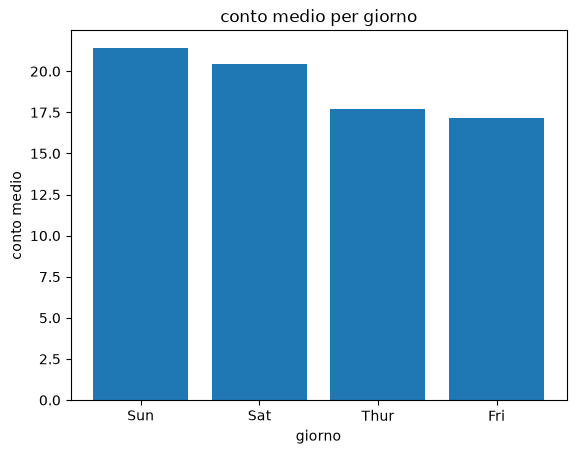

In [ ]:
#conto medio, conteggio, minimo e massimo per giorno
stats = df.groupby('day')['total_bill'].agg(['mean', 'count', 'min', 'max'])
print('statistiche total_bill per day: \n', stats)

#nuova colonna conto_per_persona
df['conto_per_persona'] = df['total_bill']/df['size']
df.head(10)

#giorno con conto medio più alto
media = df.groupby('day')['total_bill'].mean()
media

mass = media.idxmax() #indice del valore massimo della media
print('giorno con il conto medio più alto: ', mass)

#rappresentazione grafica
media_ord = media.sort_values(ascending = False) #media ordinata
media_ord

plt.bar(media_ord.index, media_ord)
plt.title('conto medio per giorno')
plt.xlabel('giorno')
plt.ylabel('conto medio')
plt.show()